In [1]:
! pip install shap


! pip install ipywidgets
! jupyter nbextension enable --py widgetsnbextension



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot

Jupyter command `jupyter-nbextension` not found.
usage: jupyter [-h] [--version] [--config-dir] [--data-dir

In [2]:
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import os
import random

from PIL import Image
import numpy as np

import shap

from ipywidgets import FloatProgress

## Load the data

In [3]:
data_dir = 'F:/Liver_Fibrosis_US_processed'

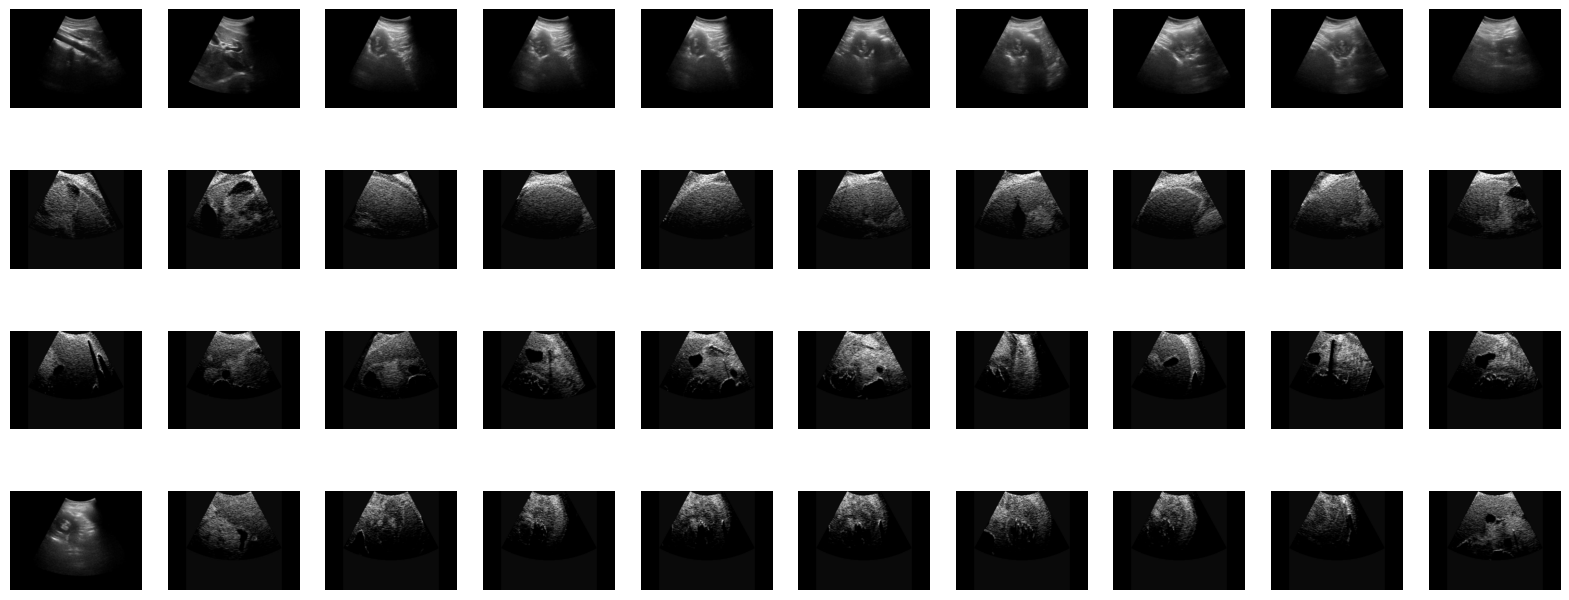

In [4]:
# Print 10 sample images from each class
classes = os.listdir(data_dir)


num_classes = len(classes)
fig, axes = plt.subplots(num_classes, 10, figsize=(20, 2 * num_classes))


for i, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    images = os.listdir(cls_path)[:10]
    for j, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        img = mpimg.imread(img_path)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
    axes[i, 0].set_ylabel(cls, size='large')

plt.show()

## Load the model

In [5]:
print("\n" + "="*80)
print("LOADING TRAINED MODELS")
print("="*80)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load Resnet50 model for US images
resnet_model_path = '../Models/Ultrasound/Resnet50/Resnet50_full_model.pt'
print(f"\nLoading Resnet50 from: {resnet_model_path}")
resnet_model = torch.load(resnet_model_path, map_location=device, weights_only=False)
resnet_model.eval()
print("✅ Resnet50 loaded successfully")


LOADING TRAINED MODELS
Using device: cpu

Loading Resnet50 from: ../Models/Ultrasound/Resnet50/Resnet50_full_model.pt
✅ Resnet50 loaded successfully
✅ Resnet50 loaded successfully


In [6]:
print(resnet_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Get prediction from the model

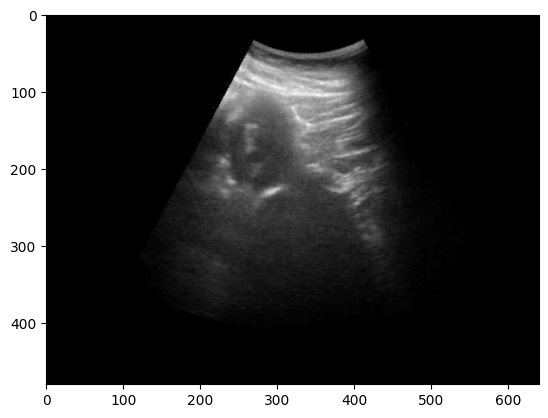

In [7]:
image = os.path.join(data_dir, 'F1', 'a13.jpg')


img = mpimg.imread(image)
plt.imshow(img, cmap='gray')

In [8]:
# Convert to numpy array
arr = np.array(img)

# If grayscale, duplicate channels to make 3 channels
if arr.ndim == 2:
    arr = np.stack([arr, arr, arr], axis=-1)

# Discard the alpha channel if present
elif arr.shape[2] == 4:
    arr = arr[:, :, :3]

# Convert to float32 and scale to [0,1]
arr = arr.astype(np.float32)
if arr.max() > 1.0:
    arr /= 255.0


input_tensor = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(device)
test_img_arr = arr

# Inference
with torch.no_grad():
    output = resnet_model(input_tensor)
    pred = int(output.argmax(dim=1).item())

target = 0
target_name = classes[target]
pred_name = classes[pred]
print(f"Target: {target_name} ({target}) | Predicted: {pred_name} ({pred})")

Target: F1 (0) | Predicted: F1 (0)


### Explain predictions with SHAP

Build background dataset

In [9]:
classes = os.listdir(data_dir)
print(f"Classes found: {classes}")

Classes found: ['F1', 'F2', 'F3', 'F4']


In [10]:
background = []
num_background = 52

per_class_background = num_background // len(classes)

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    images = os.listdir(cls_path)
    selected_images = random.sample(images, per_class_background)
    print(f"Selected images for class '{cls}': {selected_images}")
    for img_name in selected_images:
        img_path = os.path.join(cls_path, img_name)
        img = mpimg.imread(img_path)
        
        # Convert to numpy array
        arr = np.array(img)

        # If grayscale, duplicate channels to make 3 channels
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr], axis=-1)

        # Discard the alpha channel if present
        elif arr.shape[2] == 4:
            arr = arr[:, :, :3]

        # Convert to float32 and scale to [0,1]
        arr = arr.astype(np.float32)
        if arr.max() > 1.0:
            arr /= 255.0

        background.append(arr)

print(f"Background dataset size: {len(background)} images")

# Convert background list to a stacked tensor
background = np.array(background)  # Shape: (num_background, H, W, 3)
background_tensor = torch.from_numpy(background).permute(0, 3, 1, 2).to(device)

print(f"Background tensor shape: {background_tensor.shape}")

Selected images for class 'F1': ['O2258.jpg', 'ct2-33.png', 'l8525.jpg', 'g6482.jpg', 'c30.jpg', 'c8713.jpg', 'b24.jpg', 'B5835.jpg', 'c16.jpg', 'e8743.jpg', 'R3689.jpg', 'c5019.jpg', 'c1182.jpg']
Selected images for class 'F2': ['l4977.jpg', 'M7847.jpg', 'v115.jpg', 'ct3-44.png', 'W8855.jpg', 'J6388.jpg', 'i9574.jpg', 't3982.jpg', 't8800.jpg', 'ct4-3.png', 'X7359.jpg', 'ct3-41.png', 'M7341.jpg']
Selected images for class 'F3': ['n4169.jpg', 'M8130.jpg', 'n6728.jpg', 'X7248.jpg', 'M4711.jpg', 'z4244.jpg', 'ct11-41.png', 'ct11-69.png', 'u301.jpg', 'ct8-57.png', 'm7319.jpg', 'k7334.jpg', 'Q802.jpg']
Selected images for class 'F4': ['m3357.jpg', 'f9291.jpg', 'h5732.jpg', 'O2949.jpg', 'p5683.jpg', 'j7271.jpg', 'j3786.jpg', 'F9201.jpg', 'h7572.jpg', 'F9300.jpg', 'H8130.jpg', 'Q6806.jpg', 'n1705.jpg']
Selected images for class 'F3': ['n4169.jpg', 'M8130.jpg', 'n6728.jpg', 'X7248.jpg', 'M4711.jpg', 'z4244.jpg', 'ct11-41.png', 'ct11-69.png', 'u301.jpg', 'ct8-57.png', 'm7319.jpg', 'k7334.jpg', 

Fix in place ReLU operations
- Resnet50 uses in-place ReLU by default
- So the original values get overwritten
- For SHAP, during backpropagation, we need the original values

In [11]:
def disable_inplace_activations(model):
    """Recursively disable inplace operations in ReLU layers"""
    for module in model.modules():
        if isinstance(module, torch.nn.ReLU):
            module.inplace = False
    return model

resnet_model = disable_inplace_activations(resnet_model)
resnet_model.eval()

print("✅ In-place operations disabled for SHAP compatibility")


✅ In-place operations disabled for SHAP compatibility


In [ ]:
e = shap.DeepExplainer(resnet_model, background_tensor)

# Prepare test image
test_img_tensor = torch.from_numpy(test_img_arr[np.newaxis, ...]).permute(0, 3, 1, 2).to(device)
print(f"Test image tensor shape: {test_img_tensor.shape}")

# Get SHAP values
shap_values = e.shap_values(test_img_tensor)

print(f"SHAP values shape: {len(shap_values)} outputs")
for i, sv in enumerate(shap_values):
    print(f"  Class {i} ({classes[i]}): {sv.shape}")